
# 4. Análisis básico de datos 



## 4.1. Matríz de correlación entre variables

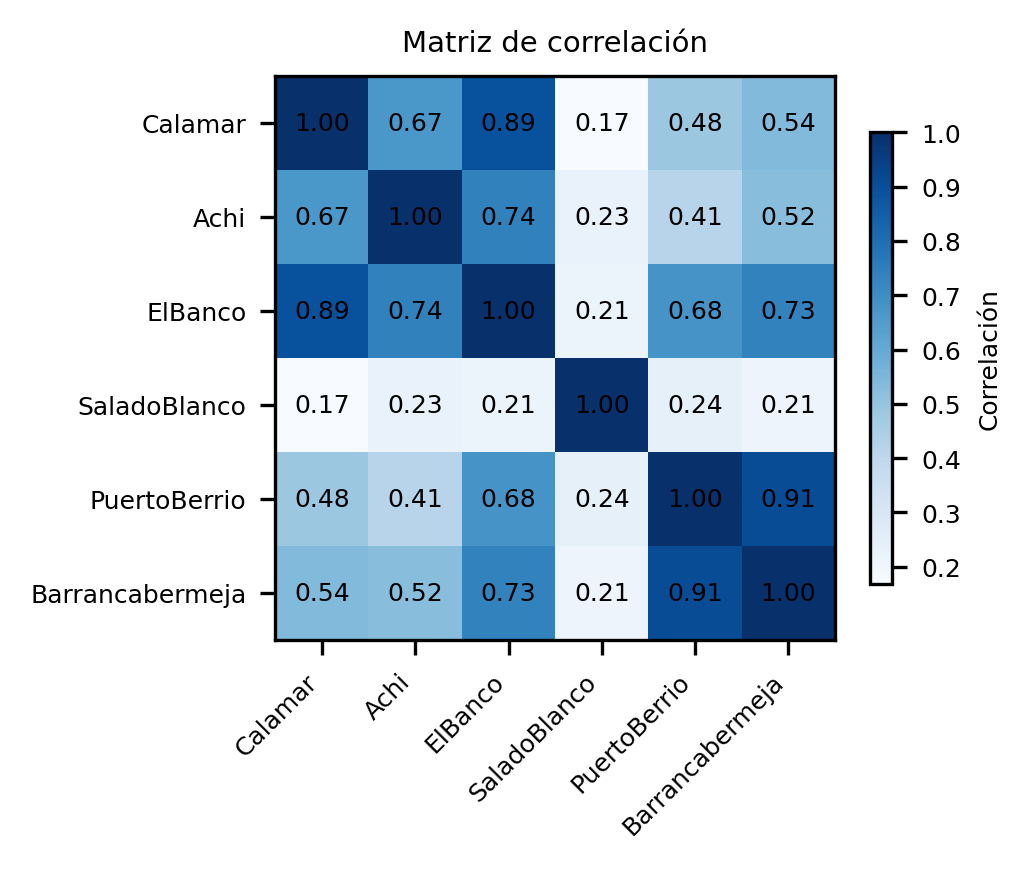

In [41]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Matriz de correlación
ruta = r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_alineados.csv"
df = pd.read_csv(ruta, parse_dates=["Fecha"])

corr = df[["Calamar", "Achi", "ElBanco","SaladoBlanco", "PuertoBerrio","Barrancabermeja"]].corr().round(3)

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300)
im = ax.imshow(corr, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=6)
ax.set_yticklabels(corr.index, fontsize=6)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)

cbar = plt.colorbar(im, ax=ax, label="Correlación", shrink=0.8)
cbar.ax.tick_params(labelsize=6)
cbar.set_label("Correlación", fontsize=6)

plt.title("Matriz de correlación", fontsize=7)
plt.tight_layout()
plt.show()

## 4.2. Diagramas de dispersión

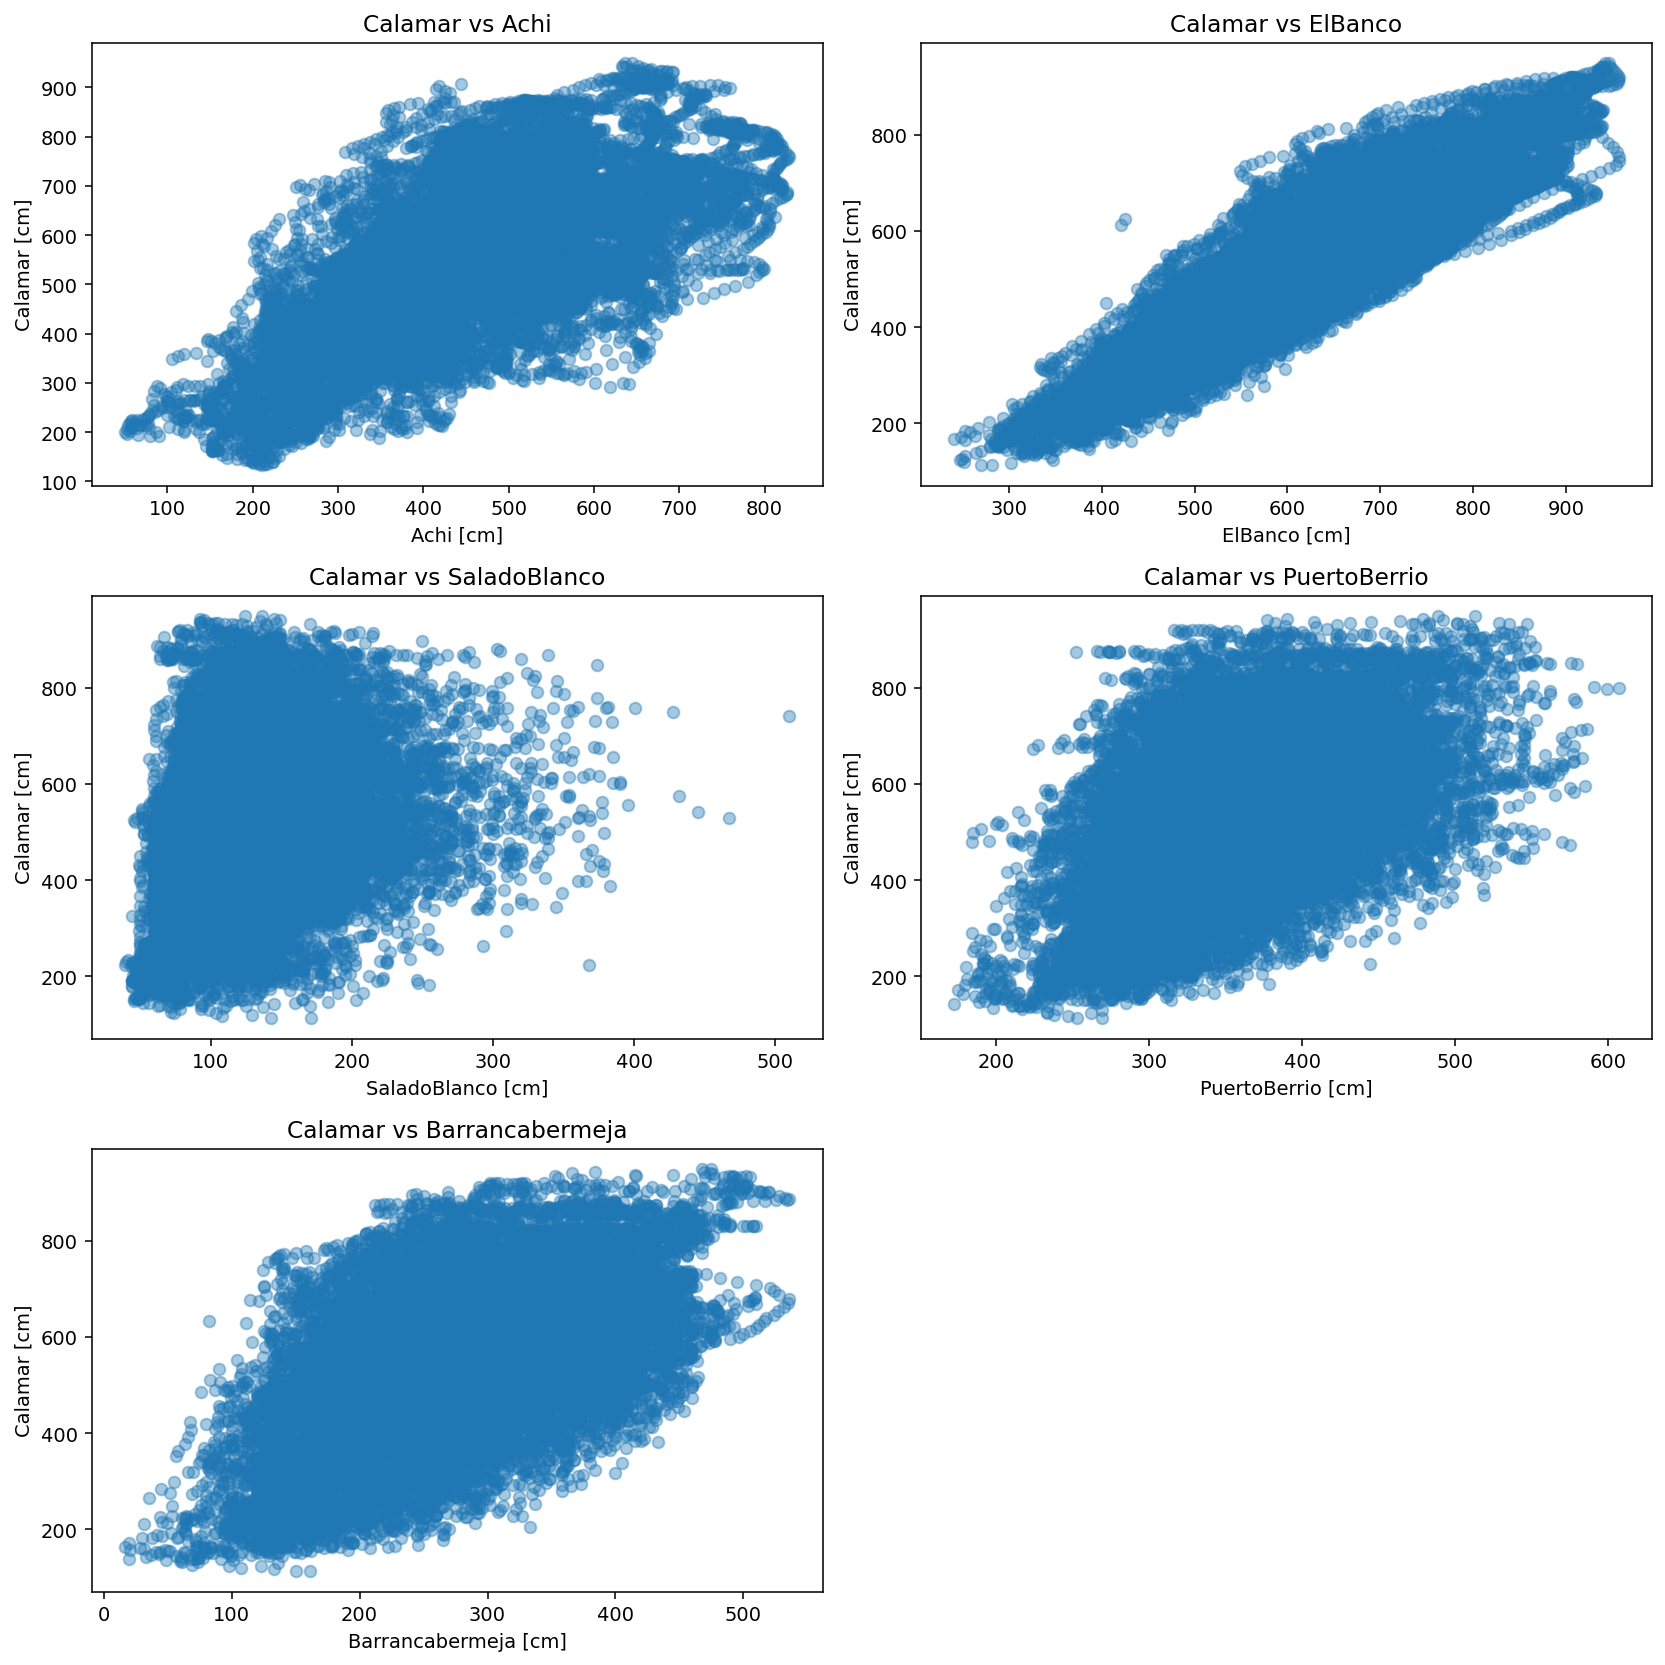

In [36]:
import math
import matplotlib.pyplot as plt

target = "Calamar"
explicativas = ["Achi", "ElBanco", "SaladoBlanco", "PuertoBerrio", "Barrancabermeja"]

n = len(explicativas)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows), dpi=140)
axes = axes.flatten()

for ax, est in zip(axes, explicativas):
    ax.scatter(df[est], df[target], alpha=0.4)
    ax.set_title(f"{target} vs {est}")
    ax.set_xlabel(f"{est} [cm]")
    ax.set_ylabel(f"{target} [cm]")

# Ocultar ejes vacíos si sobran
for j in range(len(explicativas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4.3. Factor de inflacion de la Varianza (VIF)

In [37]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seleccionar solo las variables explicativas
X = df[["Achi", "ElBanco","SaladoBlanco", "PuertoBerrio","Barrancabermeja"]].dropna().copy()

# Calcular VIF
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)
vif_df

,Variable,VIF
0,PuertoBerrio,85.968766
1,ElBanco,78.607905
2,Barrancabermeja,42.148871
3,Achi,28.258192
4,SaladoBlanco,9.712156
